# Thermal Observables of a Heisenberg Spin Chain

This notebook uses `thermal_gibbs_workflow` to estimate finite-temperature observables for a small antiferromagnetic Heisenberg chain. The Gibbs state weights the chain's energy eigenstates, allowing thermal energy and nearest-neighbor correlations to be computed from the package-generated polynomial density matrix.

## Notebook guide

- **Learning objective:** estimate thermal observables of a finite Heisenberg spin chain.
- **Prerequisites:** an editable repository install, the relevant tutorial workflow, and basic spectral linear algebra.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](09_phonon_density_of_states.ipynb) · [next](11_disordered_transport_localization.ipynb).


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a finite spin-1/2 Heisenberg chain with isotropic nearest-neighbor coupling. Its thermal energy and spin correlations describe how a quantum magnet changes with temperature.

**QSVT implementation.** `thermal_gibbs_workflow` approximates the Boltzmann operator $e^{-\beta H}$ by a polynomial, normalizes it into a Gibbs density matrix, and returns dense reference diagnostics. The notebook uses that density matrix for package-client observables.

**Classical reference and quantum relevance.** Exact matrix exponentiation through the package's dense spectral reference validates the finite chain. In a QSVT setting, the same imaginary-time polynomial is the transform core once a block encoding of the spin Hamiltonian and a measurement strategy for observables are supplied.

## Variable definitions

- $H=J\sum_{i=1}^{n-1}(X_iX_{i+1}+Y_iY_{i+1}+Z_iZ_{i+1})$ is the open Heisenberg Hamiltonian.
- $\beta=(k_BT)^{-1}$ is inverse temperature, with $k_B=1$ in the dimensionless model.
- $\rho_\beta=e^{-\beta H}/Z$ is the Gibbs state and $Z=\operatorname{Tr}(e^{-\beta H})$ is the partition function.
- $E_\beta=\operatorname{Tr}(\rho_\beta H)$ is the thermal energy.
- $C_{zz}=\frac{1}{n-1}\sum_i\operatorname{Tr}(\rho_\beta Z_iZ_{i+1})$ is the mean nearest-neighbor spin correlation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import thermal_gibbs_workflow
from qsvt.hamiltonians import heisenberg_chain, pauli_string_matrix
from qsvt.spectral import eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_spins = 4
coupling = 1.0
beta = 0.6
degree = 24

hamiltonian = heisenberg_chain(
    n_spins,
    jx=coupling,
    jy=coupling,
    jz=coupling,
    periodic=False,
)
zz_observable = np.zeros_like(hamiltonian)
for index in range(n_spins - 1):
    operators = ["I"] * n_spins
    operators[index] = "Z"
    operators[index + 1] = "Z"
    zz_observable += pauli_string_matrix("".join(operators)).real
zz_observable /= n_spins - 1

result = thermal_gibbs_workflow(
    hamiltonian,
    beta=beta,
    degree=degree,
    num_points=1201,
)
reference_gibbs = result.reference_gibbs_state
polynomial_gibbs = result.polynomial_gibbs_state
reference_energy = np.trace(reference_gibbs @ hamiltonian).real
polynomial_energy = np.trace(polynomial_gibbs @ hamiltonian).real
reference_correlation = np.trace(reference_gibbs @ zz_observable).real
polynomial_correlation = np.trace(polynomial_gibbs @ zz_observable).real
energies, energy_eigenvectors = eigh_hermitian(hamiltonian)
reference_populations = np.diag(
    energy_eigenvectors.conj().T @ reference_gibbs @ energy_eigenvectors
).real
polynomial_populations = np.diag(
    energy_eigenvectors.conj().T @ polynomial_gibbs @ energy_eigenvectors
).real

print(f"spins: {n_spins}")
print(f"inverse temperature: {beta:.2f}")
print(f"energy range: {energies[0]:.4f} to {energies[-1]:.4f}")
print(f"reference partition function: {result.reference_partition_function:.6f}")
print(f"reference thermal energy: {reference_energy:.6f}")
print(f"polynomial thermal energy: {polynomial_energy:.6f}")
print(f"reference mean ZZ correlation: {reference_correlation:.6f}")
print(f"polynomial mean ZZ correlation: {polynomial_correlation:.6f}")

spins: 4
inverse temperature: 0.60
energy range: -6.4641 to 3.0000
reference partition function: 86.235695
reference thermal energy: -4.958058
polynomial thermal energy: -4.958058
reference mean ZZ correlation: -0.550895
polynomial mean ZZ correlation: -0.550895


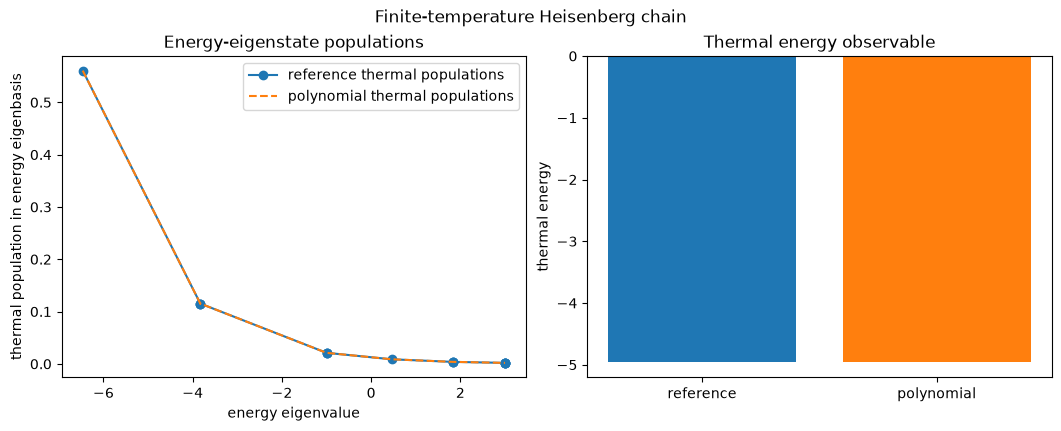

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

axes[0].plot(energies, reference_populations, "o-", label="reference thermal populations")
axes[0].plot(energies, polynomial_populations, "--", label="polynomial thermal populations")
axes[0].set_xlabel("energy eigenvalue")
axes[0].set_ylabel("thermal population in energy eigenbasis")
axes[0].set_title("Energy-eigenstate populations")
axes[0].legend()

axes[1].bar(["reference", "polynomial"], [reference_energy, polynomial_energy], color=["tab:blue", "tab:orange"])
axes[1].set_ylabel("thermal energy")
axes[1].set_title("Thermal energy observable")
fig.suptitle("Finite-temperature Heisenberg chain")
plt.show()

In [4]:
report = result.as_report()
assert report["mode"] == "thermal-gibbs-workflow"
assert result.density_matrix_relative_error < 1e-10
assert abs(polynomial_energy - reference_energy) < 1e-10
assert abs(polynomial_correlation - reference_correlation) < 1e-10
assert np.isclose(np.trace(reference_gibbs), 1.0)
assert np.isclose(np.trace(polynomial_gibbs), 1.0)

boltzmann_weights = np.exp(-beta * (energies - energies[0]))
boltzmann_weights /= boltzmann_weights.sum()
np.testing.assert_allclose(reference_populations, boltzmann_weights, rtol=1e-10, atol=1e-12)
np.testing.assert_allclose(polynomial_populations, boltzmann_weights, rtol=1e-10, atol=1e-12)
assert abs(np.dot(energies, reference_populations) - reference_energy) < 1e-10
assert abs(np.dot(energies, polynomial_populations) - polynomial_energy) < 1e-10

print(f"Gibbs density-matrix relative error: {result.density_matrix_relative_error:.3e}")
print(f"thermal energy absolute error: {abs(polynomial_energy - reference_energy):.3e}")
print(f"mean ZZ correlation absolute error: {abs(polynomial_correlation - reference_correlation):.3e}")
print("validation: passed")

Gibbs density-matrix relative error: 3.496e-15
thermal energy absolute error: 2.132e-14
mean ZZ correlation absolute error: 2.442e-15
validation: passed


## Interpretation and limitations

The population plot uses the Hamiltonian energy eigenbasis, where the exact Gibbs populations are normalized Boltzmann weights. This is a finite, dimensionless spin model evaluated with dense matrices. The polynomial Gibbs state is a validated transform proxy, not a claim of efficient thermal-state preparation or direct quantum measurement. A scalable implementation would require an explicit Hamiltonian block encoding, state preparation, and observable-estimation protocol.

## Takeaways and next steps

- **Result:** The workflow shows how to estimate thermal energy and nearest-neighbor spin correlations for a Heisenberg chain.
- **Interpretation boundary:** This is a finite, simulator-scale application client; input, readout, and scalability assumptions remain explicit.
- **Continue:** [collection index](README.md) · [previous](09_phonon_density_of_states.ipynb).

## Takeaways and next steps

- **Result:** The workflow shows how to estimate thermal observables of a finite Heisenberg spin chain.
- **Interpretation boundary:** This is a finite, simulator-scale application client; input, readout, and scalability assumptions remain explicit.
- **Continue:** [collection index](README.md) · [previous](09_phonon_density_of_states.ipynb) · [next](11_disordered_transport_localization.ipynb).
